In [ ]:
import anndata as ad 
import mudata as md 
import numpy as np
import pandas as pd 
from scipy.stats import poisson
import networkx as nx 
import matplotlib.pyplot as plt 
import networkx as nx 

**Convention**: Feature level of higher cardinality represents the index, feature level of lower cardinality represents columns

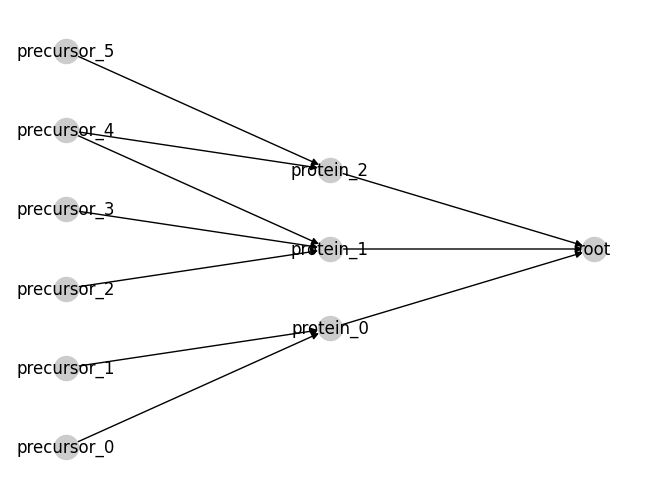

In [ ]:
edges = [
    ("precursor_0", "protein_0"),
    ("precursor_1", "protein_0"),
    ("precursor_2", "protein_1"),
    ("precursor_3", "protein_1"),
    ("precursor_4", "protein_1"),
    ("precursor_4", "protein_2"),
    ("precursor_5", "protein_2"),
    ("protein_0", "root"),
    ("protein_1", "root"),
    ("protein_2", "root")
]
graph = nx.DiGraph(
    edges
)

layout = nx.multipartite_layout(graph, align="vertical", subset_key={
    "root": ["root"], 
    # "gene": ["gene_0", "gene_1"], 
    "protein": ["protein_0", "protein_1", "protein_2"], 
    "precursor": ["precursor_0", "precursor_1", "precursor_2", "precursor_3", "precursor_4", "precursor_5"]
    })

# layout = nx.circular_layout(graph)

nx.draw(
    graph, 
    node_color="#cccccc", 
    with_labels=True, 
    pos=layout
)

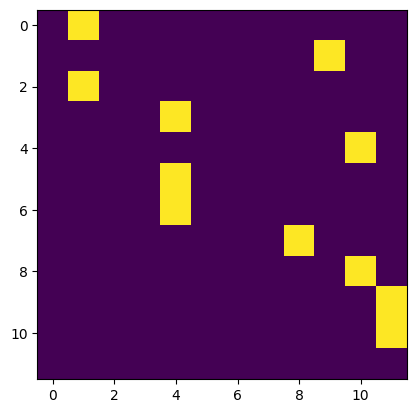

In [86]:
x = nx.to_pandas_adjacency(graph)
plt.imshow(x)

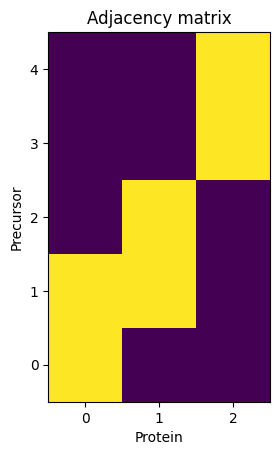

In [30]:
adjacency_matrix__precursor_proteins = pd.DataFrame(
    [
        [1, 0, 0],
        [1, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
     ], 
    index=[0, 1, 2, 3, 4], 
    columns=[0, 1, 2]
)


plt.imshow(adjacency_matrix__precursor_proteins)
plt.gca().set(ylabel="Precursor", xlabel="Protein", title="Adjacency matrix")
plt.gca().invert_yaxis()

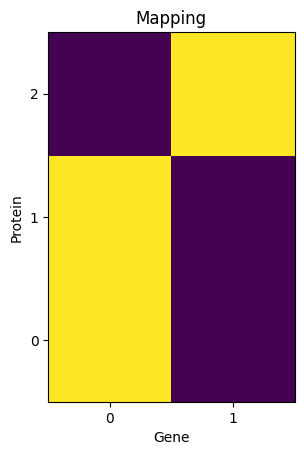

In [37]:
adjacency_matrix__protein_gene = pd.DataFrame(
    [
        [1, 0],
        [1, 0],
        [0, 1],

     ], 
    index=[0, 1, 2,], 
    columns=[0, 1]
)


plt.imshow(adjacency_matrix__protein_gene)
plt.gca().set(xlabel="Gene", ylabel="Protein", title="Mapping")
plt.yticks([0, 1, 2])
plt.xticks([0, 1])
plt.gca().invert_yaxis()

In [ ]:
def generate_hierarchical_data(n_features_per_level: int) -> dict[str, ad.AnnData] | md.MuData:
    ...

## Real world

In [ ]:
mdata = md.MuData(
    {"a": ad.źnnData(X=np.zeros(shape=(3, 20))), "b": ad.AnnData(X=np.zeros(shape=(10, 50)))}
)


mdata

/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push

MuData object with n_obs × n_vars = 10 × 70
  2 modalities
    a:	10 x 20
    b:	10 x 50

```python
# hdata: new hierarchical data format (based on mudata/anndata)

hdata[
     <observation>, <layer>, <feature>
]

```

```python
mdata[feature_type][observation, feature]
```

```python

class HierarchicalData:
    def __init__(self, levels: dict[str, layer], feature_mapping: list[np.ndarray]) -> None:
        ...

    # Create view
    def to_anndata(self, level: str) -> ad.AnnData:
        """Convert a single level to an anndata object propagating all parent levels"""

```
# required method
hdata.to_anndata(layer=...)

# 

hd.Hdata()